**Classifying Handwritten Digits with CNNs**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, Input
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


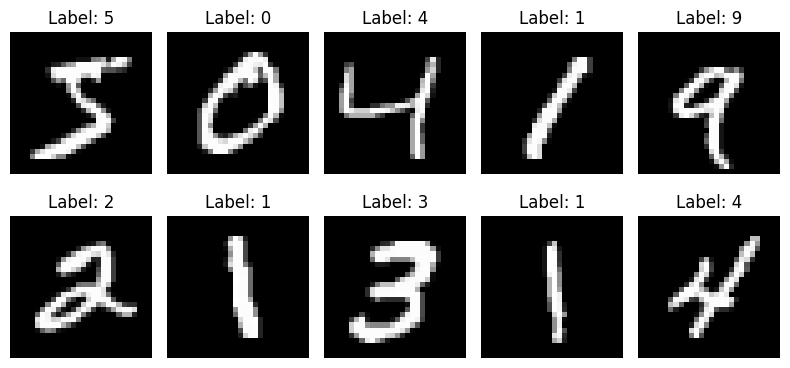

In [7]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
x_train_flat = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test_flat = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Flattened training images shape:", x_train_flat.shape)
print("Flattened test images shape:", x_test_flat.shape)
print("One-hot training labels shape:", y_train_cat.shape)
print("One-hot test labels shape:", y_test_cat.shape)

Flattened training images shape: (60000, 784)
Flattened test images shape: (10000, 784)
One-hot training labels shape: (60000, 10)
One-hot test labels shape: (10000, 10)


In [9]:
fc_model = Sequential([Input(shape=(784,)), Dense(128, activation="relu"), Dense(64, activation="relu"), Dense(10, activation="softmax")])
fc_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
fc_history = fc_model.fit(x_train_flat, y_train_cat, epochs=5, batch_size=32,validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9230 - loss: 0.2633 - val_accuracy: 0.9525 - val_loss: 0.1554
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9661 - loss: 0.1115 - val_accuracy: 0.9681 - val_loss: 0.1058
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9772 - loss: 0.0744 - val_accuracy: 0.9699 - val_loss: 0.1021
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9817 - loss: 0.0576 - val_accuracy: 0.9729 - val_loss: 0.0915
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9860 - loss: 0.0434 - val_accuracy: 0.9743 - val_loss: 0.0880


In [10]:
fc_test_loss, fc_test_accuracy = fc_model.evaluate(x_test_flat, y_test_cat)

print("Fully Connected NN Test Loss:", fc_test_loss)
print("Fully Connected NN Test Accuracy:", fc_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9768 - loss: 0.0785
Fully Connected NN Test Loss: 0.07853864133358002
Fully Connected NN Test Accuracy: 0.9768000245094299


The Fully Connected Neural Network achieved about 97.7% accuracy on the test set. This is a strong result and shows that the model learned to classify handwritten digits well. However, since the images were flattened from 28x28 into 784 pixels, the model lost the original spatial structure of the image.

In [11]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("CNN training shape:", x_train_cnn.shape)
print("CNN test shape:", x_test_cnn.shape)

CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


In [15]:
cnn_model = Sequential([Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)), MaxPooling2D((2, 2)),
                        Conv2D(64, (3, 3), activation="relu"),MaxPooling2D((2, 2)), Flatten(),
                        Dense(64, activation="relu"), Dense(10, activation="softmax")])
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_history = cnn_model.fit(x_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9508 - loss: 0.1650 - val_accuracy: 0.9805 - val_loss: 0.0643
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9844 - loss: 0.0502 - val_accuracy: 0.9852 - val_loss: 0.0485
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9880 - val_loss: 0.0406
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9916 - loss: 0.0257 - val_accuracy: 0.9856 - val_loss: 0.0482
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9935 - loss: 0.0197 - val_accuracy: 0.9881 - val_loss: 0.0403


In [16]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(x_test_cnn, y_test_cat)

print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy:", cnn_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0311
CNN Test Loss: 0.031113220378756523
CNN Test Accuracy: 0.9887999892234802


The Convolutional Neural Network achieved about 98.9% accuracy on the test set, which is higher than the Fully Connected Neural Network (~97.7%). This improvement occurs because CNNs preserve the spatial structure of the images and learn local features such as edges and shapes using convolutional filters. In contrast, the Fully Connected model flattens the image and loses this spatial information. CNNs are more suitable for image classification tasks.

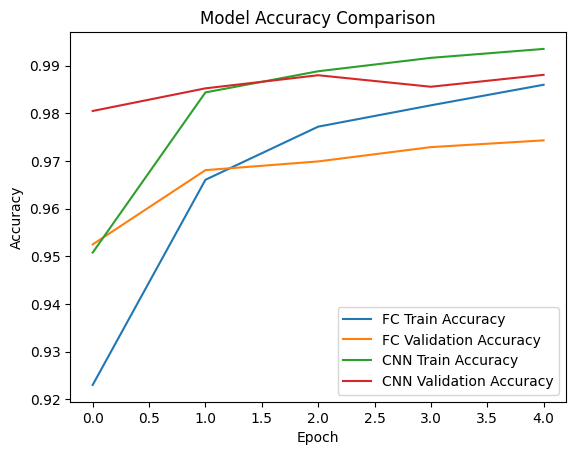

In [17]:
import matplotlib.pyplot as plt

# Plot accuracy

plt.figure()

plt.plot(fc_history.history['accuracy'], label='FC Train Accuracy')
plt.plot(fc_history.history['val_accuracy'], label='FC Validation Accuracy')

plt.plot(cnn_history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy')

plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

The graph shows that both models improve during training, but the CNN achieves higher accuracy than the Fully Connected model. The CNN also maintains better validation performance, indicating stronger generalization.

The main difference between the two models is how they process the input data. The Fully Connected model uses flattened images, which removes the spatial structure of the data. As a result, it treats each pixel independently and cannot capture patterns such as edges or shapes.

CNN keeps the 2D structure of the images and uses convolutional layers to learn local features. This allows the model to detect important visual patterns, making it more effective for image classification tasks.